In [1]:
import pandas as pd
import numpy as np

data = {
    "Order_ID": [101, 102, 103, 104, 105, 106, 107, 108],
    "Customer": ["A", "B", "A", "C", "B", "A", "A", None],
    "Product": ["Laptop", "Phone", "Tablet", "Laptop", "Phone", "Tablet", "Laptop", "Phone"],
    "Price": [800, 500, 300, 850, 520, 310, 800, 500],
    "Quantity": [1, 2, 1, 1, 3, np.nan, 1, 2]
}

df = pd.DataFrame(data)
print(df)

   Order_ID Customer Product  Price  Quantity
0       101        A  Laptop    800       1.0
1       102        B   Phone    500       2.0
2       103        A  Tablet    300       1.0
3       104        C  Laptop    850       1.0
4       105        B   Phone    520       3.0
5       106        A  Tablet    310       NaN
6       107        A  Laptop    800       1.0
7       108     None   Phone    500       2.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Order_ID  8 non-null      int64  
 1   Customer  7 non-null      object 
 2   Product   8 non-null      object 
 3   Price     8 non-null      int64  
 4   Quantity  7 non-null      float64
dtypes: float64(1), int64(2), object(2)
memory usage: 328.0+ bytes


In [8]:
# data cleaning
df['Quantity'].fillna(df['Quantity'].mean(),inplace=True)
df['Customer'].fillna('Unknown', inplace=True)
# finding the duplicate
df.duplicated()
# finding outliers
outliers = df[df['Price'] > 800]
print(outliers)
df.loc[df['Price'] > 800, 'Price'] = df['Price'].median()
#Feature Engineering
df['Total'] = df['Price'] * df['Quantity']
df
# Total revenue
df['Total'].sum()
# Top 2 customers by spending
df.groupby('Customer')['Total'].sum().sort_values(ascending=False).head(2)
# Most profitable product
df.groupby('Product')['Quantity'].sum().idxmax()
# Top product per customer
df.sort_values('Total',ascending=False).groupby('Customer').first()

<ipython-input-8-7b2307373f62>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Customer'].fillna('Unknown', inplace=True)


In [10]:
# finding the duplicate
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
dtype: bool

In [12]:
# finding outliers
outliers = df[df['Price'] > 800]
print(outliers)
df.loc[df['Price'] > 800, 'Price'] = df['Price'].median()

   Order_ID Customer Product  Price  Quantity
3       104        C  Laptop    850       1.0


In [31]:
# dynamic thresholds
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

upper = Q3 + 1.5 * IQR

df.loc[df['Price'] > upper, 'Price'] = df['Price'].median()

In [19]:
#Feature Engineering
df['Total'] = df['Price'] * df['Quantity']
df

,Order_ID,Customer,Product,Price,Quantity,Total
0,101,A,Laptop,800,1.000000,800.000000
1,102,B,Phone,500,2.000000,1000.000000
2,103,A,Tablet,300,1.000000,300.000000
3,104,C,Laptop,510,1.000000,510.000000
4,105,B,Phone,520,3.000000,1560.000000
5,106,A,Tablet,310,1.571429,487.142857
6,107,A,Laptop,800,1.000000,800.000000
7,108,Unknown,Phone,500,2.000000,1000.000000


In [18]:
# Total revenue
df['Total'].sum()

np.float64(6457.142857142857)

In [20]:
# Top 2 customers by spending
df.groupby('Customer')['Total'].sum().sort_values(ascending=False).head(2)

Customer
B    2560.000000
A    2387.142857
Name: Total, dtype: float64

In [22]:
# Most Sold product
df.groupby('Product')['Quantity'].sum().idxmax()


'Phone'

In [32]:
# Most Profitable product
df.groupby('Product')['Total'].sum().idxmax()
# here the product are calculated based on the total here 'Revenue' is calculated. when it comes to quantity most sold product is counted

'Phone'

In [25]:
# Top product per customer
df.sort_values('Total',ascending=False).groupby('Customer').first()

,Order_ID,Product,Price,Quantity,Total
Customer,,,,,
A,101,Laptop,800,1.0,800.0
B,105,Phone,520,3.0,1560.0
C,104,Laptop,510,1.0,510.0
Unknown,108,Phone,500,2.0,1000.0


In [27]:
# Customers with repeat purchases
# Customers with Repeat Purchases (Customers buying same product again → loyalty)
repeat_customers = df.groupby(['Customer', 'Product']).size().reset_index(name='count')

repeat_customers = repeat_customers[repeat_customers['count'] > 1]
print(repeat_customers)

  Customer Product  count
0        A  Laptop      2
1        A  Tablet      2
2        B   Phone      2


In [35]:
df.rename(columns={"Total": "Revenue"}, inplace=True)

In [36]:
df

,Order_ID,Customer,Product,Price,Quantity,Revenue
0,101,A,Laptop,505.0,1.000000,800.000000
1,102,B,Phone,500.0,2.000000,1000.000000
2,103,A,Tablet,300.0,1.000000,300.000000
3,104,C,Laptop,510.0,1.000000,510.000000
4,105,B,Phone,520.0,3.000000,1560.000000
5,106,A,Tablet,310.0,1.571429,487.142857
6,107,A,Laptop,505.0,1.000000,800.000000
7,108,Unknown,Phone,500.0,2.000000,1000.000000


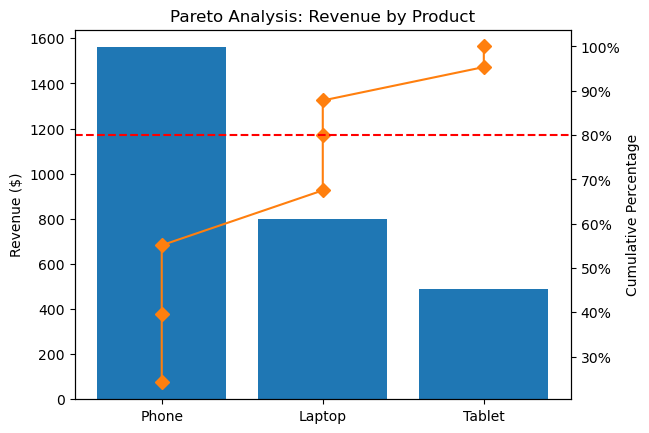

In [38]:
# pareto chart based on 80% revenue
'''visualizes the 80/20 rule, showing that a small percentage of customers or products (approx. 20%) generates the vast majority
(approx. 80%) of revenue.80% of company's revenue comes from 20% of total customers. 2) 80% of company's revenue comes from 20% of total products.'''
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
#Sort and calculate cumulative percentage
df = df.sort_values(by='Revenue', ascending=False)
df['cum_percentage'] = df['Revenue'].cumsum() / df['Revenue'].sum() * 100

# 3. Create the Pareto Chart
fig, ax = plt.subplots()

# Bar chart for Revenue
ax.bar(df['Product'], df['Revenue'], color="C0")
ax.set_ylabel("Revenue ($)")

# Line chart for Cumulative Percentage (Secondary Axis)
ax2 = ax.twinx()
ax2.plot(df['Product'], df['cum_percentage'], color="C1", marker="D", ms=7)
ax2.yaxis.set_major_formatter(PercentFormatter())
ax2.set_ylabel("Cumulative Percentage")

# 4. Add 80% threshold line
ax2.axhline(80, color="red", linestyle="--", label="80% Threshold")

plt.title("Pareto Analysis: Revenue by Product")
plt.show()


In [ ]:
#Detect low-performing products
from scipy.stats import zscore
df['z'] = zscore(df['Price'])
outliers = df[df['z'].abs() > 3]

In [ ]:
#Build customer segments automatically

